# Day 14 — Week 2 大收官：MLP vs GCN vs GAT

今天不再学新的 GNN 算子，而是做一个完整 mini project：

> **同一数据集、同一 split、同一训练流程，对比 MLP / GCN / GAT，回答：graph structure 到底带来了什么？**

## 今日目标

完成后你应该能回答：

1. MLP、GCN、GAT 的输入分别是什么？
2. 为什么 MLP 看不到 graph structure？
3. GCN 和 GAT 都利用邻居，它们的 aggregation 区别是什么？
4. 在同一数据集上，谁表现更好？为什么不能仅凭一次实验下结论？
5. 如果破坏 graph structure，GCN / GAT 会发生什么？
6. embedding 可视化能告诉我们什么？
7. 错误节点通常有什么结构特征？
8. graph structure 的贡献该怎么验证，而不是“凭感觉”？

## Deliverables

- MLP / GCN / GAT
- 同一训练/评估 pipeline
- accuracy 对比
- embedding 2D 可视化
- error analysis
- graph-structure ablation
- Week 2 最终复盘

## 0. 一句话先定调

```text
MLP:
x
↓
predict

GCN / GAT:
x + edge_index
↓
message passing
↓
predict
```

今天最核心的问题是：

> **当 node feature 相同的时候，额外加入 graph topology，是否能带来更好的 representation / prediction？**

In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv, GATConv

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

D:\anaconda\envs\graph-learning\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


device: cpu


## 1. Dataset：Cora

Cora 是经典 citation graph：

- node = paper
- edge = citation relation
- node feature = bag-of-words feature
- label = paper category

我们用它做 node classification。

> 第一次运行时，PyG 会自动下载数据。

In [2]:
dataset = Planetoid(root="data/Cora", name="Cora")
data = dataset[0].to(device)

print(data)
print()
print("num_nodes:", data.num_nodes)
print("num_edges:", data.num_edges)
print("num_features:", dataset.num_features)
print("num_classes:", dataset.num_classes)
print("train nodes:", int(data.train_mask.sum()))
print("val nodes:", int(data.val_mask.sum()))
print("test nodes:", int(data.test_mask.sum()))

Processing...


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

num_nodes: 2708
num_edges: 10556
num_features: 1433
num_classes: 7
train nodes: 140
val nodes: 500
test nodes: 1000


Done!


### 必须回答 1

为什么今天对比 MLP / GCN / GAT 时，必须：

- 用同一个 dataset
- 用同一套 train / val / test split
- 尽量使用相近的 hidden dimension / epoch / optimizer

你的回答：为了控制变量，保证三种模型的实验条件尽可能一致，使最终性能差异主要来自模型本身（MLP / GCN / GAT 的 architecture 和是否、如何利用 graph structure），而不是来自不同的数据划分、训练轮数或优化器等外部因素。

## 2. 三个模型

我们尽量让三者结构接近：

```text
MLP:
features → hidden → logits

GCN:
features → GCN hidden → GCN logits

GAT:
features → multi-head GAT hidden → GAT logits
```

注意：MLP 完全不接收 `edge_index`；GCN / GAT 都接收 `edge_index`。

In [23]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.5):
        super().__init__()
        self.lin1 = nn.Linear(in_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index=None, return_embedding=False):
        h = self.lin1(x)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        logits = self.lin2(h)
        if return_embedding:
            return logits,h
        return logits

class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index, return_embedding=False):
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        logits = self.conv2(h, edge_index)
        if return_embedding:
            return logits,h
        return logits

class GAT(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads=4, dropout=0.5):
        super().__init__()
        self.conv1 = GATConv(
            in_dim,
            hidden_dim,
            heads=heads,
            concat=True,
            dropout=dropout
        )
        self.conv2 = GATConv(
            hidden_dim*heads,
            out_dim,
            heads=1,
            concat=False,
            dropout=dropout
        )
        
        self.dropout = dropout

    def forward(self, x, edge_index, return_embedding=False):
        h = self.conv1(x, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        logits = self.conv2(h, edge_index)
        if return_embedding:
            return logits,h
        return logits

### 必须回答 2

下面三句话分别对应哪个模型？

```text
A. 我只学习 node feature → label 的 mapping
B. 我用 degree-normalized graph aggregation 聚合邻居
C. 我用 learnable attention coefficient 决定不同邻居的重要性
```

你的回答：A -> MLP , B -> GCN, C -> GAT

### 必须回答 3

为什么上面的 GAT 第二层输入是：

```python
hidden_dim * heads
```

而不是：

```python
hidden_dim
```

你的回答：

## 3. 统一训练 / 评估函数

公平比较最重要的一点：

> **模型可以不同，但 training protocol 尽量保持一致。**

In [24]:
def accuracy(logits, y, mask):
    pred = logits.argmax(dim=1)
    return (pred[mask] == y[mask]).float().mean().item()


def train_one_model(model, data, epochs=200, lr=0.01, weight_decay=5e-4, verbose=False):
    model = model.to(device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    history = {"loss": [], "train_acc": [], "val_acc": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits = model(data.x, data.edge_index)
        loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = model(data.x, data.edge_index)
            train_acc = accuracy(logits, data.y, data.train_mask)
            val_acc = accuracy(logits, data.y, data.val_mask)
            test_acc = accuracy(logits, data.y, data.test_mask)

        history["loss"].append(loss.item())
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["test_acc"].append(test_acc)

        if verbose and (epoch == 1 or epoch % 50 == 0):
            print(
                f"Epoch {epoch:03d} | loss={loss.item():.4f} | "
                f"train={train_acc:.3f} | val={val_acc:.3f} | test={test_acc:.3f}"
            )

    return model, history

## 4. 训练 MLP / GCN / GAT

In [25]:
in_dim = dataset.num_features
out_dim = dataset.num_classes

# 让三种模型的中间表示规模大致接近，而不是死抠完全相同参数量。
mlp = MLP(in_dim, hidden_dim=16, out_dim=out_dim)
gcn = GCN(in_dim, hidden_dim=16, out_dim=out_dim)
gat = GAT(in_dim, hidden_dim=8, out_dim=out_dim, heads=2)

mlp, hist_mlp = train_one_model(mlp, data, verbose=True)
print("\nMLP done\n")

gcn, hist_gcn = train_one_model(gcn, data, verbose=True)
print("\nGCN done\n")

gat, hist_gat = train_one_model(gat, data, verbose=True)
print("\nGAT done")

Epoch 001 | loss=1.9586 | train=0.143 | val=0.114 | test=0.103
Epoch 050 | loss=0.2593 | train=1.000 | val=0.512 | test=0.503
Epoch 100 | loss=0.2272 | train=1.000 | val=0.530 | test=0.528
Epoch 150 | loss=0.2212 | train=1.000 | val=0.550 | test=0.540
Epoch 200 | loss=0.1444 | train=1.000 | val=0.554 | test=0.551

MLP done

Epoch 001 | loss=1.9486 | train=0.643 | val=0.428 | test=0.422
Epoch 050 | loss=0.0539 | train=1.000 | val=0.770 | test=0.789
Epoch 100 | loss=0.0430 | train=1.000 | val=0.762 | test=0.793
Epoch 150 | loss=0.0230 | train=1.000 | val=0.760 | test=0.796
Epoch 200 | loss=0.0195 | train=1.000 | val=0.756 | test=0.799

GCN done

Epoch 001 | loss=1.9595 | train=0.664 | val=0.374 | test=0.404
Epoch 050 | loss=0.3859 | train=1.000 | val=0.770 | test=0.798
Epoch 100 | loss=0.2603 | train=1.000 | val=0.772 | test=0.793
Epoch 150 | loss=0.3313 | train=1.000 | val=0.754 | test=0.775
Epoch 200 | loss=0.2224 | train=1.000 | val=0.762 | test=0.790

GAT done


## 5. 最终 accuracy 对比

In [26]:
def final_metrics(model, data):
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
    return {
        "train": accuracy(logits, data.y, data.train_mask),
        "val": accuracy(logits, data.y, data.val_mask),
        "test": accuracy(logits, data.y, data.test_mask),
    }

results = {
    "MLP": final_metrics(mlp, data),
    "GCN": final_metrics(gcn, data),
    "GAT": final_metrics(gat, data),
}

for name, metrics in results.items():
    print(
        f"{name:>4} | train={metrics['train']:.3f} | "
        f"val={metrics['val']:.3f} | test={metrics['test']:.3f}"
    )

 MLP | train=1.000 | val=0.554 | test=0.551
 GCN | train=1.000 | val=0.756 | test=0.799
 GAT | train=1.000 | val=0.762 | test=0.790


### 必须回答 4

根据你实际跑出来的结果回答：

1. test accuracy 谁最高？
2. MLP 和 GNN 的差距说明了什么？
3. 为什么不能根据这一次结果就说“GCN 永远比 GAT 好”或者“GAT 永远比 GCN 好”？

你的回答：

1. 本次实验中 GCN 的 test accuracy 最高，为 0.799，GAT 为 0.790，MLP 为 0.551

2. GCN 和 GAT 明显高于 MLP，说明在当前 Cora 实验中，利用 neighborhood / graph structure 能显著提升 node classification 的泛化性能。不过仅凭 MLP 与 GNN 的比较还不能完全把提升归因于 graph structure，后续还需要 structure ablation 验证

3. 不能根据一次实验认为 GCN 永远优于 GAT。本次两者 test accuracy 只相差 0.009，而且结果还受到 random seed、初始化、hyperparameters、dataset 和 split 等因素影响。需要多次实验以及不同数据集才能做更可靠的比较

## 6. Training curve

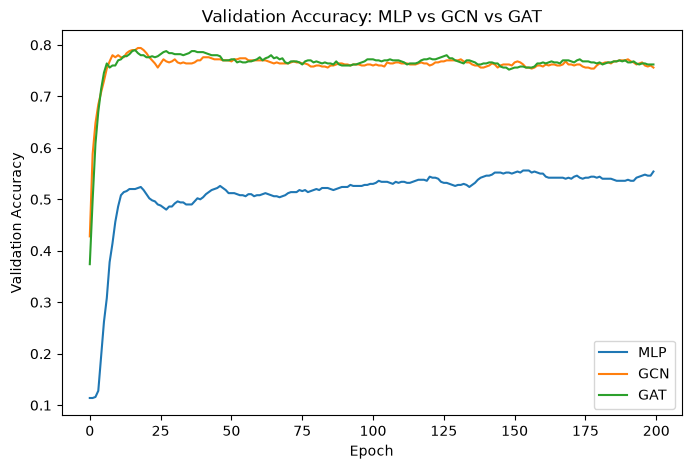

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(hist_mlp["val_acc"], label="MLP")
plt.plot(hist_gcn["val_acc"], label="GCN")
plt.plot(hist_gat["val_acc"], label="GAT")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: MLP vs GCN vs GAT")
plt.legend()
plt.show()

### 必须回答 5

观察 validation curve：

- 谁收敛更快？
- 谁波动更明显？
- multi-head GAT 一定比 GCN 更稳定吗？

不要只写“是/不是”，结合你的图回答。

回答：GCN 和 GAT 都收敛得很快，前十几个 epoch 就已经接近最终 validation accuracy；MLP 收敛更慢，而且最终明显低于两种 GNN。GCN 和 GAT 的曲线非常接近，整体都比较稳定，只存在小幅波动，因此仅从这次实验不能说 multi-head GAT 一定比 GCN 更稳定。

## 7. 抽取 hidden embeddings

现在不只看 prediction，而是看看模型内部学出的 node representation。

In [28]:
def get_embeddings(model, data):
    model.eval()
    with torch.no_grad():
        logits, h = model(data.x, data.edge_index, return_embedding=True)
    return logits.detach().cpu(), h.detach().cpu()

mlp_logits, mlp_emb = get_embeddings(mlp, data)
gcn_logits, gcn_emb = get_embeddings(gcn, data)
gat_logits, gat_emb = get_embeddings(gat, data)

print("MLP embedding:", mlp_emb.shape)
print("GCN embedding:", gcn_emb.shape)
print("GAT embedding:", gat_emb.shape)

MLP embedding: torch.Size([2708, 16])
GCN embedding: torch.Size([2708, 16])
GAT embedding: torch.Size([2708, 16])


## 8. 用 PCA 降到 2D 做 embedding visualization

这里不用 t-SNE，直接用 PyTorch PCA，减少额外依赖。

PCA 图不能证明模型“真正理解了类别”，但可以帮助观察：

> 同类 node 在 representation space 中是否更容易形成 cluster？

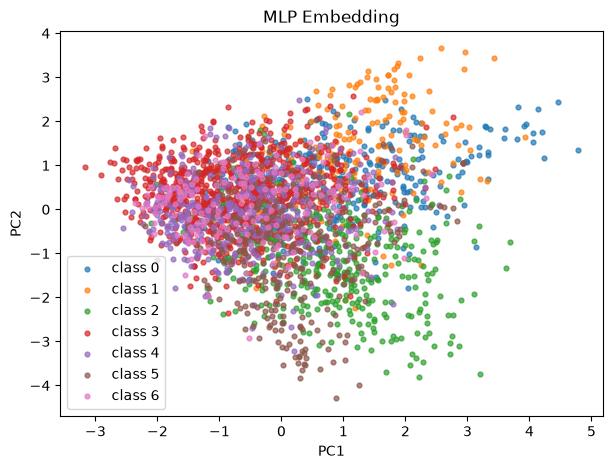

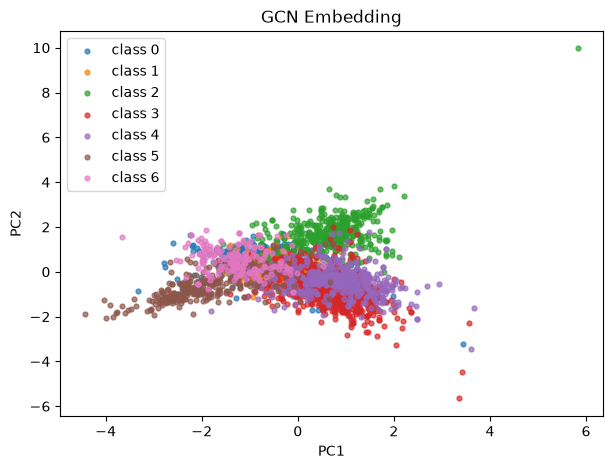

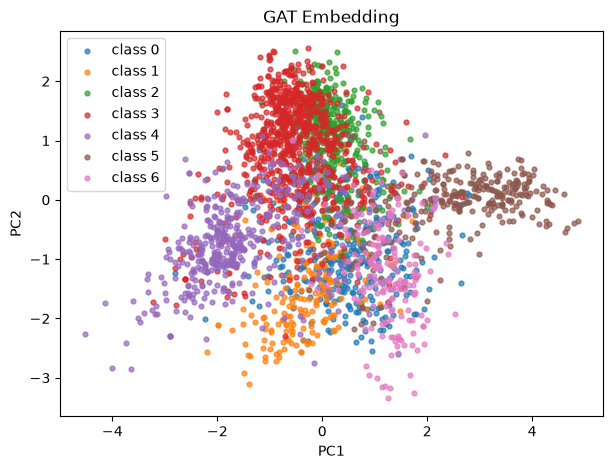

In [29]:
def pca_2d(x):
    x = x.float()
    x = x - x.mean(dim=0, keepdim=True)
    q = min(2, x.shape[1], x.shape[0])
    _, _, V = torch.pca_lowrank(x, q=q)
    return x @ V[:, :2]


def plot_embedding(emb, y, title):
    emb2d = pca_2d(emb)
    y = y.cpu()

    plt.figure(figsize=(7, 5))
    for c in torch.unique(y):
        mask = (y == c)
        pts = emb2d[mask]
        plt.scatter(pts[:, 0], pts[:, 1], label=f"class {int(c)}", s=12, alpha=0.7)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.legend()
    plt.show()

plot_embedding(mlp_emb, data.y.cpu(), "MLP Embedding")
plot_embedding(gcn_emb, data.y.cpu(), "GCN Embedding")
plot_embedding(gat_emb, data.y.cpu(), "GAT Embedding")

### 必须回答 6

看三张 embedding 图：

1. 哪个模型的 class cluster 更清晰？
2. MLP 与 GCN / GAT 的 representation 有什么视觉差异？
3. 为什么 embedding 图只能作为辅助证据，不能单独证明模型更好？

你的回答：
从图上看，GCN 和 GAT 的 class cluster 整体比 MLP 更清晰，说明利用 graph structure 后学到的 representation 在低维投影中具有更明显的类别结构。MLP 的不同类别混合更严重。GAT 某些类别的聚类较明显，但 embedding visualization 只能作为辅助证据，因为 PCA 将高维表示压缩到二维，会丢失信息，因此不能仅凭二维图判断模型性能，仍需要结合 validation/test accuracy 等定量指标。

## 9. Error Analysis：哪些 test node 被预测错了？

仅看 accuracy 会把所有错误压成一个数字。现在把错分 node 找出来。

In [30]:
def get_wrong_test_nodes(model, data):
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        pred = logits.argmax(dim=1)

    wrong_mask = data.test_mask & (pred != data.y)
    wrong_nodes = wrong_mask.nonzero(as_tuple=False).view(-1)
    return wrong_nodes, pred

wrong_mlp, pred_mlp = get_wrong_test_nodes(mlp, data)
wrong_gcn, pred_gcn = get_wrong_test_nodes(gcn, data)
wrong_gat, pred_gat = get_wrong_test_nodes(gat, data)

print("MLP wrong test nodes:", len(wrong_mlp))
print("GCN wrong test nodes:", len(wrong_gcn))
print("GAT wrong test nodes:", len(wrong_gat))

MLP wrong test nodes: 449
GCN wrong test nodes: 201
GAT wrong test nodes: 210


## 10. 看错误节点的 degree

直觉：如果一个 node 邻居很少，message passing 能利用的结构信息也更少。

但这只是 hypothesis，要看数据。

In [31]:
src, dst = data.edge_index
degree = torch.bincount(dst, minlength=data.num_nodes)


def summarize_wrong_degrees(wrong_nodes, degree, name):
    if len(wrong_nodes) == 0:
        print(name, ": no wrong test nodes")
        return
    d = degree[wrong_nodes]
    print(
        f"{name:>4} wrong-node degree | "
        f"mean={d.float().mean().item():.2f} | min={int(d.min())} | max={int(d.max())}"
    )

summarize_wrong_degrees(wrong_mlp, degree, "MLP")
summarize_wrong_degrees(wrong_gcn, degree, "GCN")
summarize_wrong_degrees(wrong_gat, degree, "GAT")

test_degree = degree[data.test_mask]
print()
print("all test-node degree | mean=", round(test_degree.float().mean().item(), 2))

 MLP wrong-node degree | mean=3.55 | min=1 | max=31
 GCN wrong-node degree | mean=3.12 | min=1 | max=15
 GAT wrong-node degree | mean=2.87 | min=1 | max=10

all test-node degree | mean= 3.71


### 必须回答 7

根据输出回答：

1. 错分节点是不是普遍 degree 更低？
2. 如果不是，也不能说明 degree 完全没关系。为什么？  
3. 除了 degree，你觉得错误还可能与什么有关？

提示：neighbor label consistency、feature ambiguity、class imbalance、noisy / heterophilic edges、training split。

1. 错分节点是不是普遍 degree 更低？
从平均值看，是的。全部 test node 的平均 degree 是 3.71，而错分节点中：
MLP：3.55
GCN：3.12
GAT：2.87
尤其 GCN 和 GAT 的错分节点平均 degree 更低，说明在这次实验中，低 degree node 更容易预测错误。

2. 如果不是，也不能说明 degree 完全没关系。为什么？
因为 degree 只是影响预测的一个因素，而且这里只比较了平均值，不能直接说明因果关系。即使某些错分节点 degree 很高，也可能因为邻居类别混杂、feature 本身模糊、局部图结构不好等原因被预测错。因此不能简单地认为 “degree 低一定错，degree 高一定对”。

3. 除了 degree，错误还可能与什么有关？
还可能和 neighbor label consistency、feature ambiguity、class imbalance、noisy / heterophilic edges、training split 等因素有关。比如一个 node 虽然邻居很多，但如果大部分邻居属于不同类别，message passing 反而可能带来误导。

## 11. Structure Contribution：破坏 graph topology

这是今天最关键的实验。

如果我们只说：

> “GCN/GAT 比 MLP 高，所以 graph structure 有用”

还不够直接。

现在保持 node features 和 labels 不变，只打乱 edge 的配对关系。

如果 GCN / GAT 性能明显下降，就能更直接说明：

$$
\text{真实 graph topology 确实贡献了可用信息}
$$

In [32]:
def rewire_edge_index(edge_index, seed=42):
    # 保留 source 列表和 destination 的 multiset，只打乱 src-dst 配对。
    g = torch.Generator(device=edge_index.device)
    g.manual_seed(seed)

    src = edge_index[0]
    perm = torch.randperm(edge_index.size(1), generator=g, device=edge_index.device)
    dst = edge_index[1][perm]

    return torch.stack([src, dst], dim=0)

rewired_edge_index = rewire_edge_index(data.edge_index, seed=SEED)

print("original edge_index:", data.edge_index.shape)
print("rewired edge_index:", rewired_edge_index.shape)

original edge_index: torch.Size([2, 10556])
rewired edge_index: torch.Size([2, 10556])


In [33]:
from copy import deepcopy

data_rewired = deepcopy(data)
data_rewired.edge_index = rewired_edge_index

重新训练 GCN / GAT。

注意：不能只把已经在真实 graph 上训练好的模型拿去喂 rewired graph，因为那会混入 train-test graph mismatch。

这里比较的是：

```text
真实 graph 上训练 + 测试
vs
打乱 graph 上训练 + 测试
```

In [34]:
gcn_rewired = GCN(in_dim, hidden_dim=16, out_dim=out_dim)
gat_rewired = GAT(in_dim, hidden_dim=8, out_dim=out_dim, heads=2)

gcn_rewired, _ = train_one_model(gcn_rewired, data_rewired, verbose=False)
gat_rewired, _ = train_one_model(gat_rewired, data_rewired, verbose=False)

rewired_results = {
    "GCN true graph": final_metrics(gcn, data)["test"],
    "GCN rewired": final_metrics(gcn_rewired, data_rewired)["test"],
    "GAT true graph": final_metrics(gat, data)["test"],
    "GAT rewired": final_metrics(gat_rewired, data_rewired)["test"],
}

for k, v in rewired_results.items():
    print(f"{k:>15}: {v:.3f}")

 GCN true graph: 0.799
    GCN rewired: 0.132
 GAT true graph: 0.790
    GAT rewired: 0.144


### 必须回答 8 —— 今天最重要的一题

根据你的实验：

> **graph structure 到底有没有贡献？**

至少回答：

1. 真 graph 与 rewired graph 的 test accuracy 有什么差异？
2. 为什么这个实验比单纯比较 MLP vs GCN 更直接？
3. 如果 rewired graph 结果偶尔没有大幅下降，可能是什么原因？

回答：

1. 真 graph 和 rewired graph 的 test accuracy 差异非常大。GCN 从 0.799 降到 0.132，GAT 从 0.790 降到 0.144，几乎降到了 7 类随机猜测的水平。这说明正确的 graph topology 对这两个 GNN 的分类性能贡献很大。

2. 这个实验比单纯比较 MLP vs GCN 更直接，因为这里尽量保持 node features、labels、dataset、split、模型和训练流程不变，只改变 graph topology。因此性能下降更能被归因于 graph structure 被破坏，而不是模型类型本身的其他差异。

3. 如果 rewired graph 的结果没有明显下降，可能有几种原因：node features 本身已经足够强，模型没有真正依赖 graph structure；原图的 topology 本身信息量有限；rewiring 方式没有有效破坏关键结构；或者实验受到 random seed、超参数和训练波动影响。因此需要进一步做多次重复实验和更严格的 ablation 才能判断。

这个实验支持“Cora 上正确的 graph topology 提供了关键监督之外的信息”这一 hypothesis，但结论仍应限定在当前数据集、模型和实验设置下。

## 12. 最终对照图

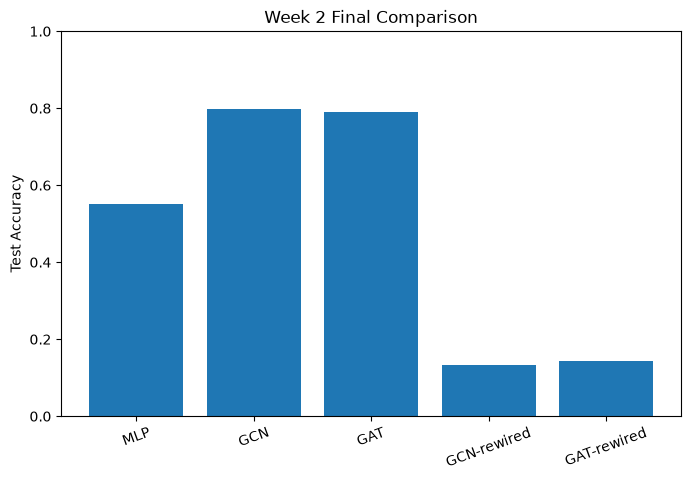

In [35]:
names = ["MLP", "GCN", "GAT", "GCN-rewired", "GAT-rewired"]
scores = [
    results["MLP"]["test"],
    results["GCN"]["test"],
    results["GAT"]["test"],
    rewired_results["GCN rewired"],
    rewired_results["GAT rewired"],
]

plt.figure(figsize=(8, 5))
plt.bar(names, scores)
plt.ylabel("Test Accuracy")
plt.title("Week 2 Final Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

## 13. MLP / GCN / GraphSAGE / GAT 最终对照表

| Model | 是否使用 graph | neighbor weighting | inductive 直觉 | 重点 |
|---|---|---|---|---|
| MLP | 否 | 无 | 只依赖 feature mapping | feature-only baseline |
| GCN | 是 | degree-normalized weights | shared graph convolution | 固定结构归一化聚合 |
| GraphSAGE | 是 | configurable aggregator | shared aggregator，可处理 unseen nodes | inductive + scalable aggregation |
| GAT | 是 | learnable attention | shared node transform + edge-wise attention rule | 动态 neighbor importance |

最值得记的一句：

> **GCN / GraphSAGE / GAT 都是在做 message passing；真正不同的是 message 如何被 transformed、weighted、aggregated。**

### 必须回答 9

不用公式，分别用一句话解释：

- GCN 和 GraphSAGE 最核心区别
- GraphSAGE 和 GAT 最核心区别
- GCN 和 GAT 最核心区别

你的回答：

GCN 和 GraphSAGE 的核心区别：GCN 将 self 和 neighbors 放进统一的 degree-normalized aggregation 中处理，而 GraphSAGE 显式地区分 self representation 和 aggregated neighbor representation，再将二者 combine

GraphSAGE 和 GAT 的核心区别：GraphSAGE 使用预先指定的 aggregator 来聚合 neighborhood，而 GAT 会学习每个 neighbor 对当前 target node 的 attention weight，从而动态决定不同 neighbors 的重要性

GCN 和 GAT 的核心区别：GCN 的 neighbor weighting rule 由 graph structure 和 degree normalization 预先决定，而 GAT 的 neighbor weights 是根据 node representations 通过 attention 动态学习出来的

## 14. Week 2 最终总复盘

```text
Graph
↓
node + edge
↓
representation learning
↓
message passing

m_{u→v}
↓
aggregate neighbors
↓
update h_v

                ┌──────── GCN
                │  structure-defined normalized aggregation
                │
Message Passing ├──────── GraphSAGE
                │  configurable + sampling-friendly aggregation
                │
                └──────── GAT
                   learnable attention-weighted aggregation
```

统一公式直觉：

$$
h_v^{(l)}
=
\mathrm{UPDATE}
\left(
h_v^{(l-1)},
\mathrm{AGG}
\left\{
\mathrm{MESSAGE}(h_u^{(l-1)},h_v^{(l-1)})
:
u\in N(v)
\right\}
\right)
$$

GCN、GraphSAGE、GAT 的区别，本质上都可以放进这个框架里理解。

# Week 2 最终必答题

请尽量不翻前面的答案。

### 1.
为什么 MLP 无法利用 graph topology，而 GCN / GAT 可以？

### 2.
什么叫 message passing？

### 3.
GCN 为什么不是简单 mean neighbor？

### 4.
GraphSAGE 为什么强调 inductive？

### 5.
GAT 的

$$
\alpha_{vu}
$$

到底表示什么？

### 6.
为什么 GAT 的 softmax 是 local neighborhood softmax，而不是 global-edge softmax？

### 7.
为什么 multi-head GAT 的输出 dimension 可能乘 `heads`？

### 8.
GAT 的 inductive capability 和它的 edge-wise attention rule 是什么关系？

### 9.
MLP / GCN / GAT 同数据集对比，真正要控制哪些变量？

### 10.
如何通过实验而不是直觉证明 graph structure 有贡献？

---

## 最后一题

用你自己的话完成：

> **GNN 的核心不是“把 graph 丢进 neural network”，而是 ________。**

你的回答：

> **GNN 的核心不是“把 graph 丢进 neural network”，而是利用 graph structure 定义信息如何在节点之间传播，并通过共享的 message-passing rule 学习 node representations**

# Day 14 完成标准

如果你已经：

- 跑通 MLP / GCN / GAT
- 能解释三者差异
- 看过 embedding
- 做过 error analysis
- 跑过 rewired-graph ablation
- 能独立回答最后 10 题

那么：

# Week 2 正式结束 ✅

下一阶段就不应该再停留在“这个 API 怎么写”，而是逐渐进入：

> **为什么某种 GNN architecture 在某种 graph / task 上有效？**

这才是后面真正和论文、科研连接起来的地方。